# **Checking Residual Spatial Autocorrelation**

**Outputs** (saved under `Output_data_from_spatial_autocorr_check_scripts`):

pickle files
* `residuals_dict_with_location.pkl`

csv file
* moran_i_results_sorted.csv

Visualisations
* Moran's I values bar plot
* Moran's I, z-scores, an dp-values table
* LISA's categories bar plot
* LISA results on the map


**Start date:** *Nov 12, 2025*<br>
**Authors:** *Kanaha Shoji*

In [ ]:
import sys
import pandas as pd
import geopandas as gpd
import libpysal
import esda
import seaborn as sns
import matplotlib.pyplot as plt
import contextily as ctx
import pickle
import numpy as np
from libpysal.weights import KNN
from esda.moran import Moran
import os
from esda import Moran_Local
from matplotlib import gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

print("seaborn:", sns.__version__)
print("contextily:", ctx.__version__)
print("python:", sys.executable)
print("pandas:", pd.__version__)
print("geopandas:", gpd.__version__)
print("libpysal:", libpysal.__version__)
print("esda:", esda.__version__)

seaborn: 0.13.2
contextily: 1.7.0
python: /Users/shoji/opt/anaconda3/envs/picklefix/bin/python
pandas: 1.5.3
geopandas: 1.0.1
libpysal: 4.13.0
esda: 2.7.0


In [8]:
base_dir = '/Users/shoji/Library/CloudStorage/OneDrive-epfl.ch/2025_03_Melbourne_walkability_study_final/urban-walkability-insights'
saved_file_dir = os.path.join(base_dir,'Output_data_from_spatial_autocorr_check_scripts')
modeling_dir = os.path.join(base_dir,'Output_data_from_modeling_scripts')
processing_file_dir = os.path.join(base_dir,'Output_data_from_processing_scripts')

In [9]:
# Load saved datasets
with open(os.path.join(processing_file_dir, 'processed_melbourne_data_for_modeling.csv'), 'rb') as f:
    processed_melbourne_data = pd.read_csv(f) # without coordinates and location id randamized
with open(os.path.join(processing_file_dir, 'melbourne_data_before_corr_filtering.csv'), 'rb') as f:
    processed_melbourne_data_before_corr_filtering = pd.read_csv(f) # with coordinates

In [10]:
coordinates = processed_melbourne_data_before_corr_filtering[["Location_id", "Latitude", "Longitude"]].drop_duplicates()
coordinates

,Location_id,Latitude,Longitude
0,2.0,-37.813807,144.965167
93260,4.0,-37.814880,144.966088
180593,6.0,-37.819117,144.965583
273660,8.0,-37.822935,144.947175
365534,10.0,-37.818765,144.947105
458592,11.0,-37.815650,144.939707
550573,14.0,-37.820112,144.962919
639176,18.0,-37.813449,144.973054
732672,19.0,-37.812372,144.965507
786714,20.0,-37.811729,144.968247


In [11]:
processed_melbourne_data[["Location_id", "Longitude"]]

,Location_id,Longitude
0,2.0,144.965167
1,2.0,144.965167
2,2.0,144.965167
3,2.0,144.965167
4,2.0,144.965167
...,...,...
2437509,62.0,144.962165
2437510,62.0,144.962165
2437511,62.0,144.962165
2437512,62.0,144.962165


In [12]:
import sys, pandas as pd
print(sys.executable)
print(pd.__version__)
print(pd.__file__)

/Users/shoji/opt/anaconda3/envs/picklefix/bin/python
1.5.3
/Users/shoji/opt/anaconda3/envs/picklefix/lib/python3.10/site-packages/pandas/__init__.py


In [13]:
# Load saved models and test sets
with open(os.path.join(modeling_dir,'all_models_reproduced_w_location_id.pkl'), 'rb') as f:
    all_models = pickle.load(f)

with open(os.path.join(modeling_dir,'all_model_tests_x_y_location_id.pkl'), 'rb') as f:
    all_model_tests = pickle.load(f)

In [14]:
with open(os.path.join(modeling_dir,'location_id.pkl'), 'rb') as f:
    all_model_location_id = pickle.load(f)

with open(os.path.join(modeling_dir,'location_map.pkl'), 'rb') as f:
    location_map = pickle.load(f)

In [15]:
# Choose one model/dataset that failed
model = all_models["cat_models"]["All"]
x_test_df = all_model_tests["cat_x_test"]["All"]

print("Model feature names:", model.feature_names_[:30])
print("x_test_df columns:", list(x_test_df.columns)[:30])

Model feature names: ['Visual complexity mean', '5 Building use diversity', '5 Job count', 'Temperature', '5 Walkable path length', 'Elderly', '15 Building use diversity', '5 Tree density', 'Road view mean', 'Year', 'Month', '5 Lamp density', 'Longitude', 'Footprint mean', '5 Bench density', '15 Dwelling count', 'Location id', '15 Job count', 'Building view mean', 'Day type', '15 Green area', '15 Bench density', 'Hour']
x_test_df columns: ['Visual complexity mean', '5 Building use diversity', '5 Job count', 'Temperature', '5 Walkable path length', 'Elderly', '15 Building use diversity', '5 Tree density', 'Road view mean', 'Year', 'Month', '5 Lamp density', 'Longitude', 'Footprint mean', '5 Bench density', '15 Dwelling count', 'Location id', '15 Job count', 'Building view mean', 'Day type', '15 Green area', '15 Bench density', 'Hour']


In [16]:
coordinates['Location_id'].unique()

array([ 2.,  4.,  6.,  8., 10., 11., 14., 18., 19., 20., 21., 27., 29.,
       35., 37., 39., 43., 51., 53., 54., 58., 59., 24., 25., 36., 41.,
       44., 45., 46., 49., 50., 52., 56.,  1.,  3.,  5.,  9., 12., 17.,
       23., 28., 30., 31., 40., 42., 47., 48., 55., 61., 62.])

In [17]:
location_map

{2.0: 2749,
 4.0: 3786,
 6.0: 744,
 8.0: 8132,
 10.0: 515,
 11.0: 7890,
 14.0: 6636,
 18.0: 5636,
 19.0: 8990,
 20.0: 4298,
 21.0: 8759,
 27.0: 3344,
 29.0: 4844,
 35.0: 8874,
 37.0: 8538,
 39.0: 3801,
 43.0: 3107,
 51.0: 1084,
 53.0: 2397,
 54.0: 5018,
 58.0: 7366,
 59.0: 7040,
 24.0: 1948,
 25.0: 8962,
 36.0: 422,
 41.0: 3995,
 44.0: 4228,
 45.0: 9656,
 46.0: 9645,
 49.0: 4589,
 50.0: 825,
 52.0: 5240,
 56.0: 118,
 1.0: 842,
 3.0: 1602,
 5.0: 2680,
 9.0: 4958,
 12.0: 2816,
 17.0: 8952,
 23.0: 8401,
 28.0: 9922,
 30.0: 6385,
 31.0: 3996,
 40.0: 540,
 42.0: 4124,
 47.0: 2672,
 48.0: 42,
 55.0: 55,
 61.0: 9242,
 62.0: 1846}

In [18]:
# Reverse the location map
reverse_location_map = {v: k for k, v in location_map.items()}

# Initialize residuals_dict
residuals_dict = {model_name: {} for model_name in ["cat", "lgb", "xgb"]}

# Loop through models
for model_name in ["cat", "lgb", "xgb"]:
    model_set = all_models[f"{model_name}_models"]
    x_test_set = all_model_tests[f"{model_name}_x_test"]
    y_test_set = all_model_tests[f"{model_name}_y_test"]
    location_id_set = all_model_location_id[f"{model_name}"]

    # Loop through each dataset in this model set
    for dataset_name, model in model_set.items():
        x_test_df = x_test_set[dataset_name]
        y_test = y_test_set[dataset_name]
        location_ids_from_test = location_id_set[dataset_name]  # <-- This is the right-hand side IDs

        # Map test location IDs back to original
        mapped_location_ids = location_ids_from_test.map(reverse_location_map)

        # Merge with coordinates to get latitude/longitude
        x_test_with_coords = pd.DataFrame({
            "Location_id": location_ids_from_test,
            "mapped_Location_id": mapped_location_ids})

        x_test_with_coords = x_test_with_coords.merge(
            coordinates,
            left_on="mapped_Location_id",
            right_on="Location_id",
            how="left",
            suffixes=("", "_coord"))

        # Predict and calculate residuals
        y_pred = model.predict(x_test_df)
        residuals = y_test.values - y_pred

        # Build residuals DataFrame
        res_df = pd.DataFrame({
            "y_true": y_test.values,
            "y_pred": y_pred,
            "residual": residuals,
            "Latitude": x_test_with_coords["Latitude"].values,
            "Longitude": x_test_with_coords["Longitude"].values,
            "Location_id": x_test_with_coords["Location_id"].values  # original mapped ID in test
        }, index=y_test.index)

        # Store in dictionary
        residuals_dict[model_name][dataset_name] = res_df

In [19]:
residuals_dict['cat']['All']

,y_true,y_pred,residual,Latitude,Longitude,Location_id
341765,245.0,288.086333,-43.086333,-37.822935,144.947175,8132
2320279,38.0,29.152988,8.847012,-37.809993,144.972276,540
1976681,551.0,375.581825,175.418175,-37.814580,144.942924,2816
155312,3384.0,3252.210993,131.789007,-37.814880,144.966088,3786
1137411,306.0,597.886714,-291.886714,-37.798445,144.964118,3107
...,...,...,...,...,...,...
1831970,10.0,-38.826033,48.826033,-37.819830,144.951026,4958
239466,62.0,91.207651,-29.207651,-37.819117,144.965583,744
792337,149.0,224.823809,-75.823809,-37.811729,144.968247,4298
2112788,67.0,37.853058,29.146942,-37.819093,144.954527,8401


In [20]:
# # Save residuals_dict 
# with open(os.path.join(saved_file_dir,'residuals_dict_with_location.pkl'), 'wb') as f:
#     pickle.dump(residuals_dict, f)

## Moran's I (Global Spatial Autocorrelation)

In [14]:
def compute_moran_knn(res_df, k_neighbors=5):
    """
    Compute Moran's I at the sensor level by aggregating residuals per sensor.
    """
    df = res_df.dropna(subset=["Latitude", "Longitude", "residual"]).copy()

    # Aggregate residuals to one value per sensor
    sensor_df = df.groupby(["Latitude", "Longitude"])["residual"].mean().reset_index() # mean()

    # Coordinates
    coords = np.array(list(zip(sensor_df["Longitude"], sensor_df["Latitude"])))

    # KNN weights
    w = KNN.from_array(coords, k=k_neighbors)
    w.transform = 'r'

    # Moran's I
    mi = Moran(sensor_df["residual"].values, w)

    return {
        "Moran_I": mi.I,
        "z_score": mi.z_sim,
        "p_value": mi.p_sim,
        "n_sensors": len(sensor_df)}

In [15]:
models = ["cat", "lgb", "xgb"]
datasets = residuals_dict["cat"].keys()

moran_results = {}

for model in models:
    moran_results[model] = {}
    for dataset_name in residuals_dict[model].keys():
        df_res = residuals_dict[model][dataset_name]
        moran_results[model][dataset_name] = compute_moran_knn(df_res, k_neighbors=5)

In [16]:
def moran_table_sorted(results):
    rows = []
    for model, datasets in results.items():
        for dataset_name, moran_res in datasets.items():
            if moran_res:  # skip None
                rows.append({
                    "model": model,
                    "dataset": dataset_name,
                    "Moran_I": moran_res["Moran_I"],
                    "z_score": moran_res["z_score"],
                    "p_value": moran_res["p_value"]
                })

    df = pd.DataFrame(rows)
    dataset_order = ["All", "Mornings", "Lunches", "Afternoons","Evenings", 
                    "Mornings Special", "Lunches Special","Afternoons Special", "Evenings Special"]
    # moran_df_sorted = moran_df.sort_values(by='dataset')
    moran_df_sorted = df.copy()
    moran_df_sorted['dataset'] = pd.Categorical(
        moran_df_sorted['dataset'], 
        categories=dataset_order, 
        ordered=True
    )

    # Sort by 'model' first, then by 'dataset'
    moran_df_sorted = moran_df_sorted.sort_values(['dataset','model']).reset_index(drop=True)
    cols = ['dataset', 'model'] + [col for col in moran_df_sorted.columns if col not in ['dataset', 'model']]
    moran_df_sorted = moran_df_sorted[cols]
    moran_df_sorted[['Moran_I', 'z_score', 'p_value']] = moran_df_sorted[['Moran_I', 'z_score', 'p_value']].round(3)
    moran_df_sorted = moran_df_sorted.reset_index(drop=True)
    moran_df_sorted['model'] = moran_df_sorted['model'].replace({
    'cat': 'CatBoost',
    'lgb': 'LightGBM',
    'xgb': 'XGBoost'})
    return moran_df_sorted

In [17]:
moran_df_sorted = moran_table_sorted(moran_results)
print(moran_df_sorted)

               dataset     model  Moran_I  z_score  p_value
0                  All  CatBoost   -0.103   -1.136    0.114
1                  All  LightGBM    0.032    0.753    0.210
2                  All   XGBoost   -0.190   -2.268    0.007
3             Mornings  CatBoost   -0.039   -0.343    0.413
4             Mornings  LightGBM   -0.156   -2.063    0.031
5             Mornings   XGBoost    0.025    0.625    0.229
6              Lunches  CatBoost   -0.158   -1.827    0.021
7              Lunches  LightGBM   -0.092   -0.983    0.166
8              Lunches   XGBoost   -0.144   -1.614    0.038
9           Afternoons  CatBoost   -0.029   -0.118    0.495
10          Afternoons  LightGBM   -0.082   -0.781    0.226
11          Afternoons   XGBoost    0.060    1.328    0.083
12            Evenings  CatBoost   -0.071   -0.665    0.265
13            Evenings  LightGBM   -0.046   -0.335    0.388
14            Evenings   XGBoost   -0.018    0.035    0.465
15    Mornings Special  CatBoost    0.03

In [28]:
# save as csv
moran_df_sorted.to_csv(os.path.join(saved_file_dir, 'moran_i_results_sorted.csv'), index=False)

In [19]:
print(moran_df_sorted['Moran_I'].max())
print(moran_df_sorted['Moran_I'].min())

0.197
-0.19


In [21]:
# load moran_df_sorted if needed
moran_df_sorted = pd.read_csv(os.path.join(saved_file_dir, 'moran_i_results_sorted.csv'))

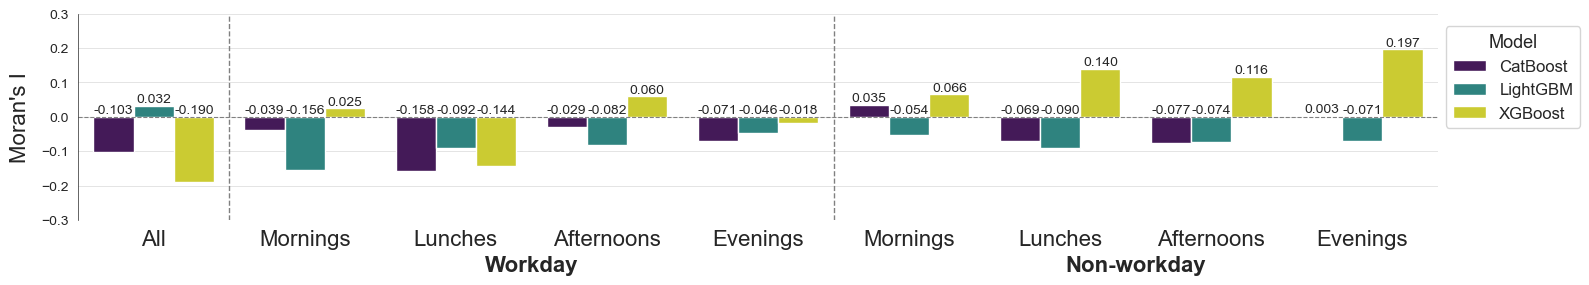

In [ ]:
plt.figure(figsize=(16,3))
sns.set_style("white")  # background white
dataset_order = [ "All", "Mornings", "Lunches", "Afternoons","Evenings", 
                          "Mornings Special", "Lunches Special", "Afternoons Special", "Evenings Special" ]
# Bar plot
ax = sns.barplot(
    data=moran_df_sorted,
    x='dataset',
    y='Moran_I',
    hue='model',
    order=dataset_order,
    palette={'CatBoost': plt.cm.viridis(0.04),
             'LightGBM': plt.cm.viridis(0.5),
             'XGBoost': plt.cm.viridis(0.96)}
)

# Remove default x-axis labels
ax.set_xticklabels([])
ax.set_xlabel("")

# Set y-axis limits
ax.set_ylim(-0.3, 0.3)

# Horizontal line at 0
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Thin horizontal grid
ax.yaxis.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax.xaxis.grid(False)

# Remove top and right spines, optionally left if you want
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)  # thin left spine
ax.spines['bottom'].set_visible(False) # remove bottom spine

# Add values above bars, with negative values shown just above 0
for p in ax.patches:
    height = p.get_height()
    
    # Skip annotation for bars with exactly 0 height
    if height == 0:
        continue
    
    # Determine y-position
    y = 0.001 if height < 0 else height + 0.001
    
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=y,
        s=f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

# Manually add top labels at custom positions
top_positions = [0, 1, 2, 3, 4, 5,6,7,8]
top_labels = ['All', 'Mornings', 'Lunches', 'Afternoons', 'Evenings', 'Mornings', 'Lunches','Afternoons', 'Evenings']
for pos, label in zip(top_positions, top_labels):
    ax.text(pos, -0.045, label, ha='center', va='top', fontsize=16, rotation=0, transform=ax.get_xaxis_transform())

# Manually add bottom group labels (Workday / Non-workday)
ax.text((1+2+3+4)/4, -0.17, 'Workday', ha='center', va='top', fontsize=16, fontweight='bold', transform=ax.get_xaxis_transform())
ax.text((5+6+7+8)/4, -0.17, 'Non-workday', ha='center', va='top', fontsize=16, fontweight='bold', transform=ax.get_xaxis_transform())

# Legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['CatBoost', 'LightGBM', 'XGBoost'], title="Model", fontsize=12, title_fontsize=13,bbox_to_anchor=(1, 0.98), loc='upper left')

# Y-axis label with smaller padding
ax.set_ylabel("Moran's I", fontsize=16, labelpad=8)
# Add vertical lines between groups
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1)  # between 'All' and 'Mornings'
ax.axvline(x=4.5, color='gray', linestyle='--', linewidth=1)  # between 'Evenings' and 'Mornings Special'
plt.tight_layout()
plt.gcf().patch.set_alpha(0.0)
# plt.savefig(os.path.join(saved_file_dir, 'SM2_moran_i_bar_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

## LISA (Local Moran's I) - detect clusters

In [23]:
def compute_lisa_knn(res_df, k_neighbors=5, alpha=0.05):
    """
    Compute Local Moran's I (LISA) at the sensor level by aggregating residuals per sensor.
    """

    # Remove NA coordinates and residuals
    df = res_df.dropna(subset=["Latitude", "Longitude", "residual"]).copy()

    if len(df) < 3:
        print("Not enough data for LISA.")
        return None

    # ---- 1) Aggregate to sensor level ----
    sensor_df = (
        df.groupby(["Latitude", "Longitude"], as_index=False)
        .agg({"residual": "mean"})
    )

    # Coordinates as Nx2 array
    coords = np.array(list(zip(sensor_df["Longitude"], sensor_df["Latitude"])))

    # ---- 2) Build spatial weights ----
    w = KNN.from_array(coords, k=k_neighbors)
    w.transform = 'r'

    # ---- 3) Compute LISA ----
    lisa = Moran_Local(sensor_df["residual"].values, w)

    # ---- 4) Add LISA results back ----
    sensor_df["lisa_I"] = lisa.Is
    sensor_df["lisa_p"] = lisa.p_sim

    # significance flag
    sig = sensor_df["lisa_p"] < alpha
    quad = lisa.q

    # ---- 5) Human-readable cluster labels ----
    cluster_labels = np.array(["Not significant"] * len(sensor_df))

    cluster_labels[(quad == 1) & sig] = "HH (Hotspot)"
    cluster_labels[(quad == 2) & sig] = "LH"
    cluster_labels[(quad == 3) & sig] = "LL (Coldspot)"
    cluster_labels[(quad == 4) & sig] = "HL"

    sensor_df["cluster"] = cluster_labels

    return sensor_df


In [24]:
models = ["cat", "lgb", "xgb"]
datasets = residuals_dict["cat"].keys()

lisa_results = {}

for model in models:
    lisa_results[model] = {}
    for dataset_name in residuals_dict[model].keys():
        df_res = residuals_dict[model][dataset_name]
        lisa_results[model][dataset_name] = compute_lisa_knn(df_res, k_neighbors=5)

In [25]:
# Cluster types
cluster_types = ["Not significant", "HH (Hotspot)", "LL (Coldspot)", "HL", "LH"]

def lisa_table_sorted(results_all):
    # Initialize summary dataframe
    summary_rows = []
    for model in models:
        for dataset_name, df_lisa in results_all[model].items():
            
            if df_lisa is None:
                summary_rows.append({
                    "Model": model,
                    "Dataset": dataset_name,
                    **{ct: "NA" for ct in cluster_types},
                    "Total_points": "NA"})
                continue
            
            counts = df_lisa["cluster"].value_counts()
            total_points = len(df_lisa)
            
            summary_rows.append({
                "Model": model,
                "Dataset": dataset_name,
                **{ct: counts.get(ct, 0) for ct in cluster_types},
                "Total_points": total_points})

    # Convert to DataFrame
    lisa_summary_df = pd.DataFrame(summary_rows)

    # Optional: compute percentages
    for ct in cluster_types:
        lisa_summary_df[ct + " (%)"] = lisa_summary_df.apply(
            lambda row: (row[ct] / row["Total_points"] * 100) if row[ct] != "NA" else "NA", axis=1)

    # Reorder columns nicely
    cols = ["Model", "Dataset", "Total_points"] + cluster_types + [ct + " (%)" for ct in cluster_types]
    lisa_summary_df = lisa_summary_df[cols]
    return lisa_summary_df

In [26]:
lisa_summary_df = lisa_table_sorted(lisa_results)

In [27]:
# Show summary without NA and only count %
lisa_summary_df_clean = lisa_summary_df[lisa_summary_df["Total_points"] != "NA"].copy()
lisa_summary_df_clean = lisa_summary_df_clean[["Model", "Dataset"] + [ct + " (%)" for ct in cluster_types]]
# Order by Dataset order and round percentages
full_index = pd.MultiIndex.from_product(
    [models, ["All", "Mornings", "Lunches", "Afternoons", "Mornings Special", "Lunches Special"]],
    names=["Model", "Dataset"]
)

lisa_summary_df_clean = (
    lisa_summary_df_clean
    .set_index(["Model", "Dataset"])
    .loc[
        lisa_summary_df_clean.set_index(["Model", "Dataset"]).index.intersection(full_index)]
    .round(2)
    .reset_index())
# Filter out rows with "NA"
lisa_summary_df_clean = lisa_summary_df[lisa_summary_df["Total_points"] != "NA"].copy()

# Keep only relevant columns
cluster_cols = [ct + " (%)" for ct in cluster_types]
lisa_summary_df_clean = lisa_summary_df_clean[["Model", "Dataset"] + cluster_cols]

# lisa_summary_df_clean[cluster_cols] = lisa_summary_df_clean[cluster_cols].astype(float).round(2)
lisa_summary_df_clean["Dataset"] = pd.Categorical(lisa_summary_df_clean["Dataset"],
                                                  categories=dataset_order,
                                                  ordered=True)
lisa_summary_df_clean = lisa_summary_df_clean.sort_values(["Dataset", "Model"]).reset_index(drop=True)

lisa_summary_df_clean

,Model,Dataset,Not significant (%),HH (Hotspot) (%),LL (Coldspot) (%),HL (%),LH (%)
0,cat,All,92.000000,0.000000,4.000000,2.000000,2.000000
1,lgb,All,84.000000,8.000000,0.000000,4.000000,4.000000
2,xgb,All,88.000000,0.000000,0.000000,4.000000,8.000000
3,cat,Mornings,90.000000,2.000000,0.000000,6.000000,2.000000
4,lgb,Mornings,92.000000,4.000000,0.000000,2.000000,2.000000
5,xgb,Mornings,92.000000,2.000000,2.000000,4.000000,0.000000
6,cat,Lunches,90.000000,2.000000,0.000000,6.000000,2.000000
7,lgb,Lunches,90.000000,0.000000,0.000000,4.000000,6.000000
8,xgb,Lunches,94.000000,0.000000,0.000000,0.000000,6.000000
9,cat,Afternoons,96.000000,0.000000,0.000000,4.000000,0.000000


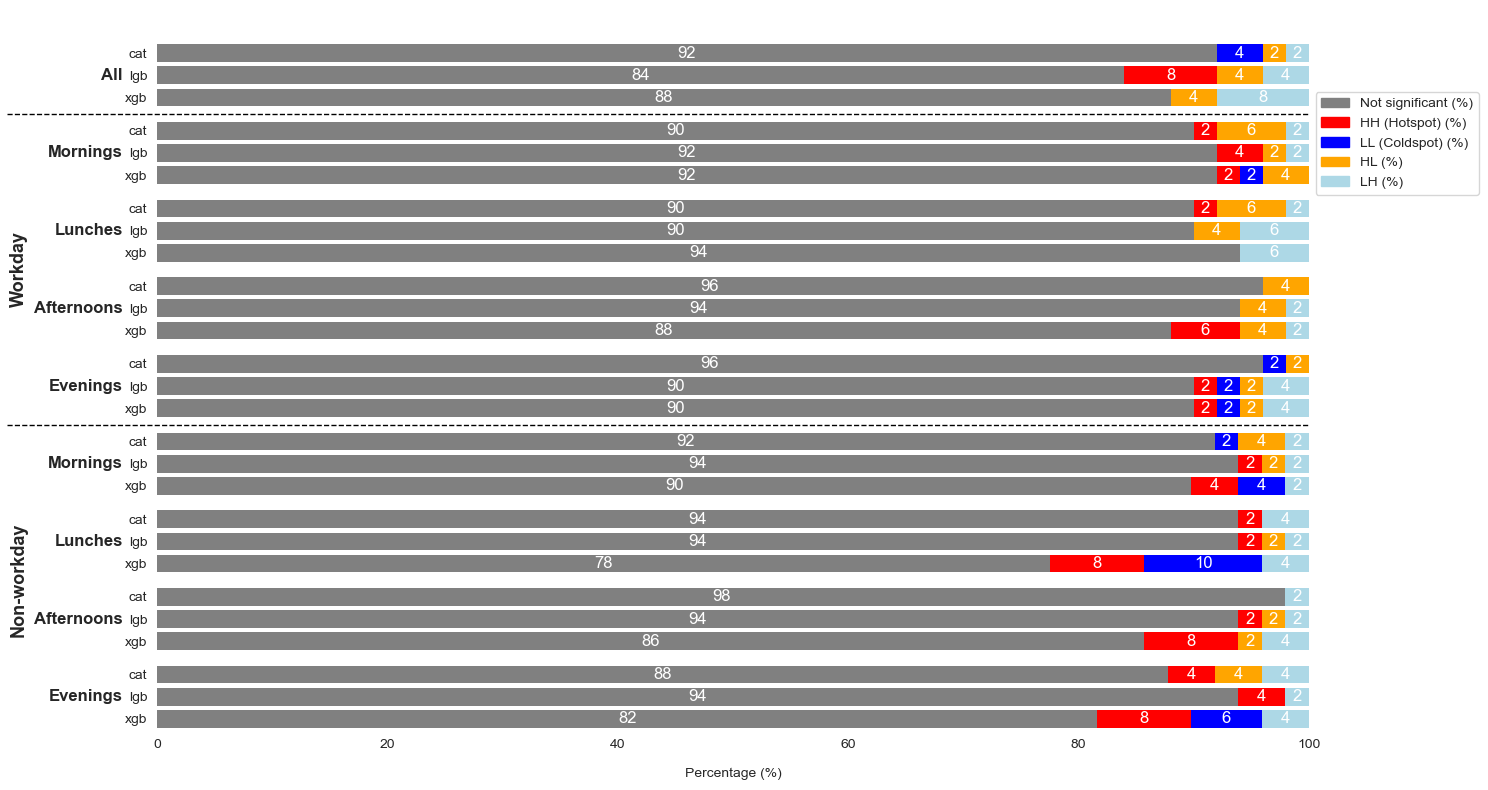

In [ ]:
# Cluster columns and colors
cluster_cols = ['Not significant (%)', 'HH (Hotspot) (%)',
                'LL (Coldspot) (%)', 'HL (%)', 'LH (%)']
colors = ['grey', 'red', 'blue', 'orange', 'lightblue']

# Original datasets and models
datasets = dataset_order
models = lisa_summary_df_clean['Model'].unique()

# Flip datasets top-to-bottom
datasets_flipped = datasets[::-1]
# Flip models within each dataset
models_flipped = models[::-1]

# Adjustable spacing between datasets
space_between_datasets = 0.5

# Build y-positions
y_positions_dict = {}  # (Dataset, Model) -> y_idx
dataset_positions_flipped = {}  # Dataset -> middle y_idx for label
pos = 0
for ds in datasets_flipped:
    dataset_positions_flipped[ds] = pos + (len(models_flipped)-1)/2
    for m in models_flipped:
        y_positions_dict[(ds, m)] = pos
        pos += 1
    pos += space_between_datasets

# Determine Workday / Non-workday
workday_datasets = ['Mornings', 'Lunches', 'Afternoons', 'Evenings']
nonworkday_datasets = ['Mornings Special', 'Lunches Special', 'Afternoons Special', 'Evenings Special']

group_positions = {}
for group_name, group_datasets in [('Workday', workday_datasets), ('Non-workday', nonworkday_datasets)]:
    y_vals = [y_positions_dict[(ds, m)] for ds in group_datasets for m in models if (ds, m) in y_positions_dict]
    group_positions[group_name] = (min(y_vals), max(y_vals))

# Plot bars
fig, ax = plt.subplots(figsize=(15,8))
for ds in datasets_flipped:
    for m in models_flipped:
        row = lisa_summary_df_clean[(lisa_summary_df_clean['Dataset']==ds) &
                                    (lisa_summary_df_clean['Model']==m)]
        if not row.empty:
            y_idx = y_positions_dict[(ds, m)]
            left = 0
            for col, color in zip(cluster_cols, colors):
                val = row.iloc[0][col]
                if val > 0:
                    ax.barh(y_idx, val, left=left, color=color, edgecolor='none')
                    if val > 1:
                        ax.text(left + val/2, y_idx, f'{val:.0f}', va='center', ha='center', color='white', fontsize=12)
                left += val

# Y-axis labels (model names)
ax.set_yticks(list(y_positions_dict.values()))
ax.set_yticklabels(list(models_flipped)*len(datasets_flipped))

# Dataset labels on the left (rename specials only for display)
display_labels = {ds: ds for ds in datasets_flipped}
display_labels.update({'Mornings Special': 'Mornings', 'Lunches Special': 'Lunches', 'Afternoons Special': 'Afternoons', 'Evenings Special': 'Evenings'})
for ds, pos in dataset_positions_flipped.items():
    ax.text(-3, pos, display_labels[ds], va='center', ha='right', fontsize=12, fontweight='bold')

# Workday / Non-workday labels on far left
for grp, (ymin, ymax) in group_positions.items():
    ax.text(-12, (ymin+ymax)/2, grp, va='center', ha='center', fontsize=13, fontweight='bold', rotation=90)

# Adjust x-axis
ax.tick_params(axis='x', pad=-20)  # move x-axis closer to bars
ax.set_xlabel('Percentage (%)')
ax.set_xlim(0,100)

# Remove frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
# Specify datasets after which you want a separator line

# Specify datasets after which you want a separator line
separator_after = ['Mornings', 'Mornings Special']  # adjust to your dataset names

# Draw horizontal separator lines manually, fully extended
for ds in separator_after:
    y_vals = [y_positions_dict[(ds, m)] for m in models_flipped if (ds, m) in y_positions_dict]
    if y_vals:
        y = max(y_vals) + space_between_datasets / 2 + 0.5
        
        # Add line in axes coordinates (so it scales properly)
        ax.axhline(y=y, xmin=-0.13, xmax=1, color='black', linewidth=1, linestyle='--', clip_on=False)


legend_handles = [Patch(color=c, label=l) for c, l in zip(colors, cluster_cols)]
ax.legend(handles=legend_handles, bbox_to_anchor=(1,0.9), loc='upper left')

plt.tight_layout()
# plt.savefig(os.path.join(saved_file_dir, 'SM3_lisa_cluster_bar_plot.png'), dpi=300, bbox_inches='tight')
plt.show()

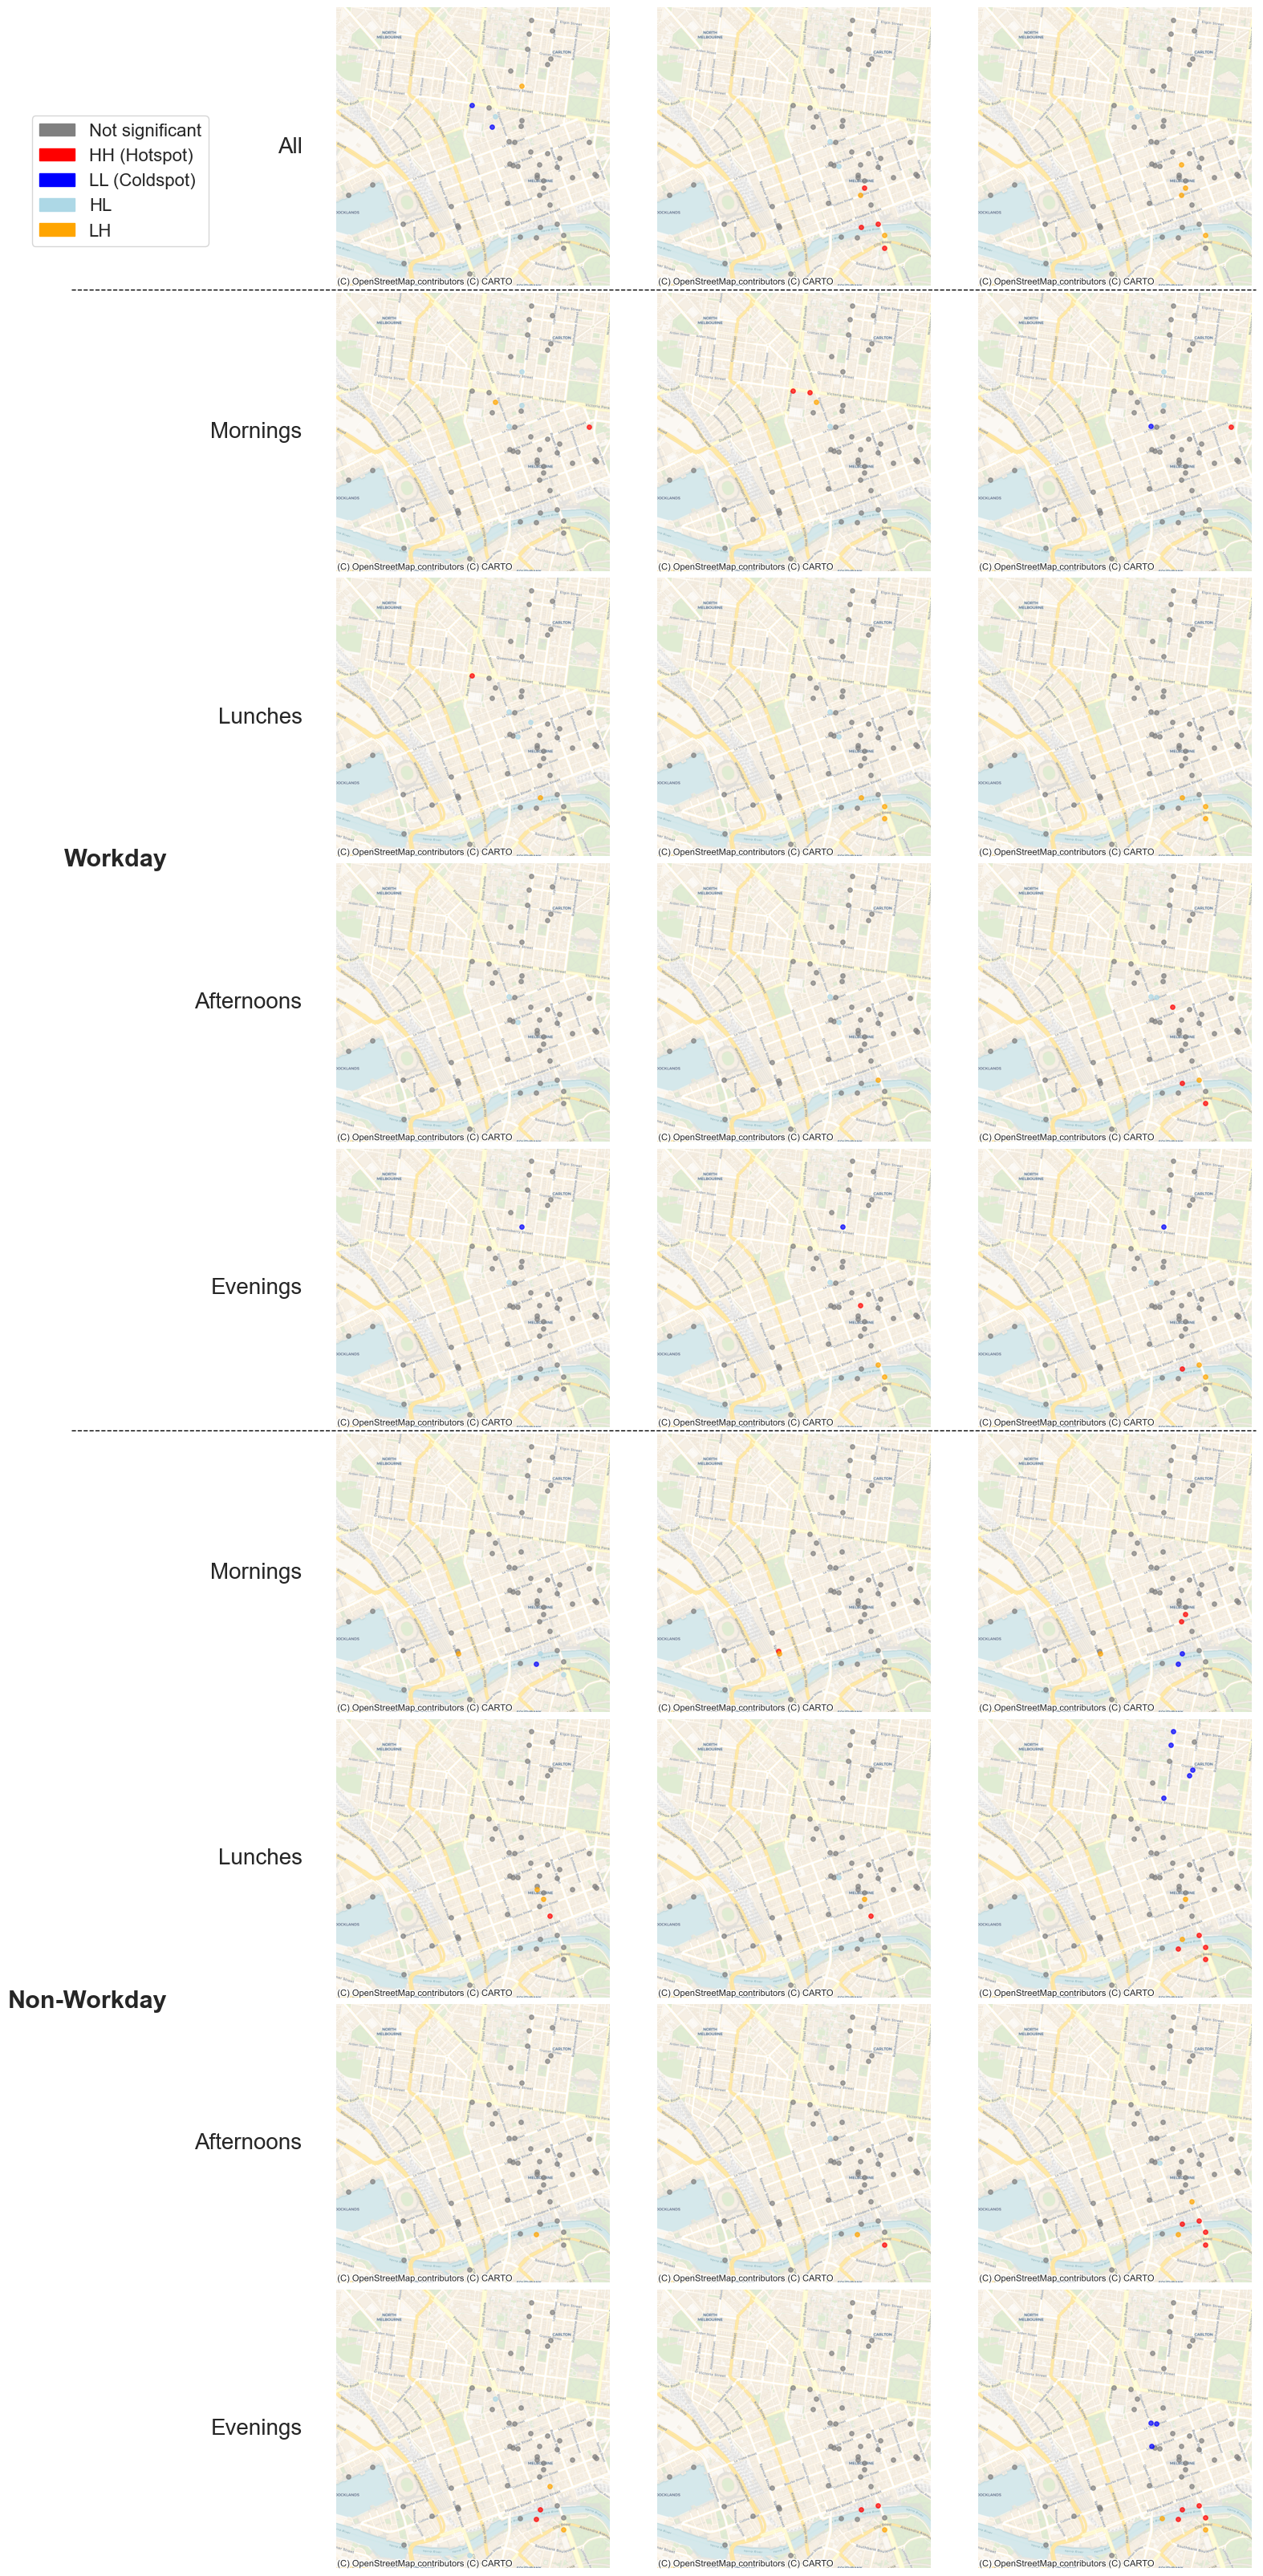

In [ ]:
colors = {
    "Not significant": "gray",
    "HH (Hotspot)": "red",
    "LL (Coldspot)": "blue",
    "HL": "lightblue",
    "LH": "orange"
}

row_heights = [1] * len(datasets)  # all rows same height
def compute_row_bottom(i):
    """Return the y-coordinate of the bottom of row i (in figure coordinates)."""
    return 1 - sum(row_heights[:i+1]) / sum(row_heights)


fig = plt.figure(figsize=(12, 32), constrained_layout=True)
gs = gridspec.GridSpec(nrows=len(datasets), ncols=len(models), figure=fig, height_ratios=row_heights)

axes = []
for i in range(len(datasets)):
    row_axes = []
    for j in range(len(models)):
        ax = fig.add_subplot(gs[i, j])
        row_axes.append(ax)
    axes.append(row_axes)

axes = np.array(axes)  # make indexing like axes[i, j] possible

# --- Now your plotting loop stays the same ---
for i, dataset_name in enumerate(datasets):
    for j, model in enumerate(models):
        ax = axes[i, j]
        
        df_lisa = lisa_results.get(model, {}).get(dataset_name, None)
        
        if df_lisa is None:
            ax.axis('off')
            continue
        
        geo_df = gpd.GeoDataFrame(df_lisa, 
                                  geometry=gpd.points_from_xy(df_lisa['Longitude'], df_lisa['Latitude']), 
                                  crs="EPSG:4326")
        geo_df = geo_df.to_crs(epsg=3857)
        
        for cluster_type, color in colors.items():
            subset = geo_df[geo_df['cluster'] == cluster_type]
            if not subset.empty:
                subset.plot(ax=ax, color=color, markersize=15, alpha=0.7)
        
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)
        ax.set_axis_off()


# Draw horizontal separator lines (in figure coordinates) 
def row_bottom(i):
    return 1 - sum(row_heights[:i+1]) / sum(row_heights)

separator_after = ['All', 'Evenings']
for i, dataset_name in enumerate(datasets):
    if dataset_name in separator_after:
        y = row_bottom(i)   # value between 0 and 1
        fig.add_artist(
            plt.Line2D([-0.25, 0.98],   # full width of figure
                        [y, y],         # y-position in figure coords
                        transform=fig.transFigure,
                        color="black",linestyle="--",linewidth=1))
        

# --- Update left-side labels (dataset names) ---
dataset_label_map = {"Mornings Special": "Mornings", "Lunches Special": "Lunches", "Afternoons Special": "Afternoons",
                      "Evenings Special": "Evenings"}

for i, dataset_name in enumerate(datasets):
    y_pos = 1 - (sum(row_heights[:i]) + row_heights[i]/2) / sum(row_heights)
    new_label = dataset_label_map.get(dataset_name, dataset_name)
    fig.text(-0.01,y_pos,new_label,va='center',ha='right',fontsize=20)

# --- Workday / Non-Workday labels ---
def compute_group_center(indices):
    return 1 - (sum([row_heights[i] for i in range(indices[0])]) + sum([row_heights[i] for i in indices])/2) / sum(row_heights)

workday_indices = [1, 2, 3,4]        # Mornings, Lunches, Afternoons, Evenings
non_workday_indices = [5,6,7,8]       # Mornings Special, Lunches Special, Afternoons Special, Evenings Special

fig.text(-0.15, compute_group_center(workday_indices), "Workday", va='center', ha='right', fontsize=22, fontweight='bold')
fig.text(-0.15, compute_group_center(non_workday_indices), "Non-Workday", va='center', ha='right', fontsize=22, fontweight='bold')

legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in colors.items()]

fig.legend(
    handles=legend_handles,
    loc="upper left",   
    bbox_to_anchor=(-0.3, 0.96), 
    ncol=1,               # stack vertically
    fontsize=16)
    # frameon=False,
    # title="Cluster Type")
# plt.savefig(os.path.join(saved_file_dir, 'SM4_lisa_cluster_maps.png'), dpi=300, bbox_inches='tight')
plt.show()